In [26]:
%pip uninstall tensorflow -y

Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Note: you may need to restart the kernel to use updated packages.


In [29]:
%pip install tensorflow==2.21.0
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#%pip install sodapy

  Using cached tensorflow-2.21.0-cp311-cp311-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
Using cached tensorflow-2.21.0-cp311-cp311-manylinux_2_27_x86_64.whl (572.4 MB)
Note: you may need to restart the kernel to use updated packages.


# Notebook de procesamiento de datos

In [36]:
%pip install scikeras

  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikeras]
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import time
import warnings
import json
from collections import Counter

# ── Datos ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OrdinalEncoder, StandardScaler, LabelEncoder, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── XGBoost ───────────────────────────────────────────────────────────────────
#from xgboost import XGBClassifier
#mport xgboost as xgb

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ── API Socrata ───────────────────────────────────────────────────────────────
from sodapy import Socrata

# ── Configuraciones globales ──────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print('✅ Entorno configurado.')
print(f'   NumPy:       {np.__version__}')
print(f'   Pandas:      {pd.__version__}')
#print(f'   XGBoost:     {xgb.__version__}')
print(f'   TensorFlow:  {tf.__version__}')


I0000 00:00:1780033961.227312  247371 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780033961.266658  247371 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Entorno configurado.
   NumPy:       1.26.4
   Pandas:      2.3.3
   TensorFlow:  2.21.0


I0000 00:00:1780033962.141755  247371 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# ── Parámetros de descarga ────────────────────────────────────────────────────
DATASET_ID = 'kgxf-xxbe'
PAGE_SIZE  = 10_000
RAW_PATH   = 'saber11_20221_20224.parquet'
PERIODOS   = ['20221', '20224']   # ÚNICAMENTE estos dos períodos

print(f'Dataset ID : {DATASET_ID}')
print(f'Page size  : {PAGE_SIZE:,} registros/bloque')
print(f'Caché path : {RAW_PATH}')
print(f'Períodos   : {PERIODOS}')


Dataset ID : kgxf-xxbe
Page size  : 10,000 registros/bloque
Caché path : saber11_20221_20224.parquet
Períodos   : ['20221', '20224']


In [3]:
# ── Descarga paginada por período ────────────────────────────────────────────
if os.path.exists(RAW_PATH):
    print(f'📂 Cargando desde caché: {RAW_PATH}')
    df_raw = pd.read_parquet(RAW_PATH)
else:
    print('🌐 Conectando a la API de datos.gov.co...')
    client = Socrata(
        'www.datos.gov.co',
        None,          # acceso anónimo (lectura pública)
        timeout=300
    )
    all_records = []

    for periodo in PERIODOS:
        print(f'\n📥 Descargando período {periodo}...')
        offset, total_periodo = 0, 0

        while True:
            try:
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )
            except Exception as e:
                print(f'⚠️  Error en offset {offset}: {e} — reintentando en 5 s...')
                time.sleep(5)
                batch = client.get(
                    DATASET_ID,
                    where=f"periodo = '{periodo}'",
                    limit=PAGE_SIZE,
                    offset=offset
                )

            if not batch:
                print(f'✅ Fin de descarga para {periodo}')
                break

            all_records.extend(batch)
            batch_size     = len(batch)
            total_periodo += batch_size
            offset        += PAGE_SIZE

            print(f'   ✔ {periodo} | batch={batch_size:,} | acum={total_periodo:,}')

            if batch_size < PAGE_SIZE:
                print(f'✅ Último bloque para {periodo}')
                break
            time.sleep(0.5)

    df_raw = pd.DataFrame.from_records(all_records)
    df_raw.to_parquet(RAW_PATH, index=False)
    print(f'\n✅ {len(df_raw):,} registros guardados en "{RAW_PATH}"')

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f'\n📊 Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print('\n📌 Registros por período:')
display(
    df_raw['periodo']
    .value_counts()
    .sort_index(ascending=False)
    .rename('Registros')
    .to_frame()
    .assign(Porcentaje_pct=lambda x: (x['Registros'] / x['Registros'].sum() * 100).round(2))
)


📂 Cargando desde caché: saber11_20221_20224.parquet

📊 Dimensiones: 1,085,937 filas × 51 columnas

📌 Registros por período:


,Registros,Porcentaje_pct
periodo,,
20224,1065888,98.1500
20221,20049,1.8500


## Definición de variables objetivo

In [4]:
# ── Variable objetivo ────────────────────────────────────────────────────────
df = df_raw.copy()
df['punt_global'] = pd.to_numeric(df['punt_global'], errors='coerce')

#LABELS = ['Muy Bajo', 'Bajo', 'Aceptable', 'Bueno', 'Excelente']
#BINS   = [0, 232, 270, 310, 360, 500]

#LABELS = ['Bajo', 'Básico', 'Alto']
#BINS   = [0, 225, 335, 500]

LABELS = ['Bajo', 'Alto']
BINS   = [0, 250, 500]

df['nivel_desempeno'] = pd.cut(
    df['punt_global'], bins=BINS, labels=LABELS,
    include_lowest=True, right=True
)

print('✅ Variable objetivo creada: nivel_desempeno')
dist = df['nivel_desempeno'].value_counts().reindex(LABELS)
pct  = (dist / dist.sum() * 100).round(2)
display(pd.DataFrame({'Clase': LABELS, 'Conteo': dist.values, '% Total': pct.values}))


✅ Variable objetivo creada: nivel_desempeno


,Clase,Conteo,% Total
0,Bajo,565188,52.0500
1,Alto,520749,47.9500


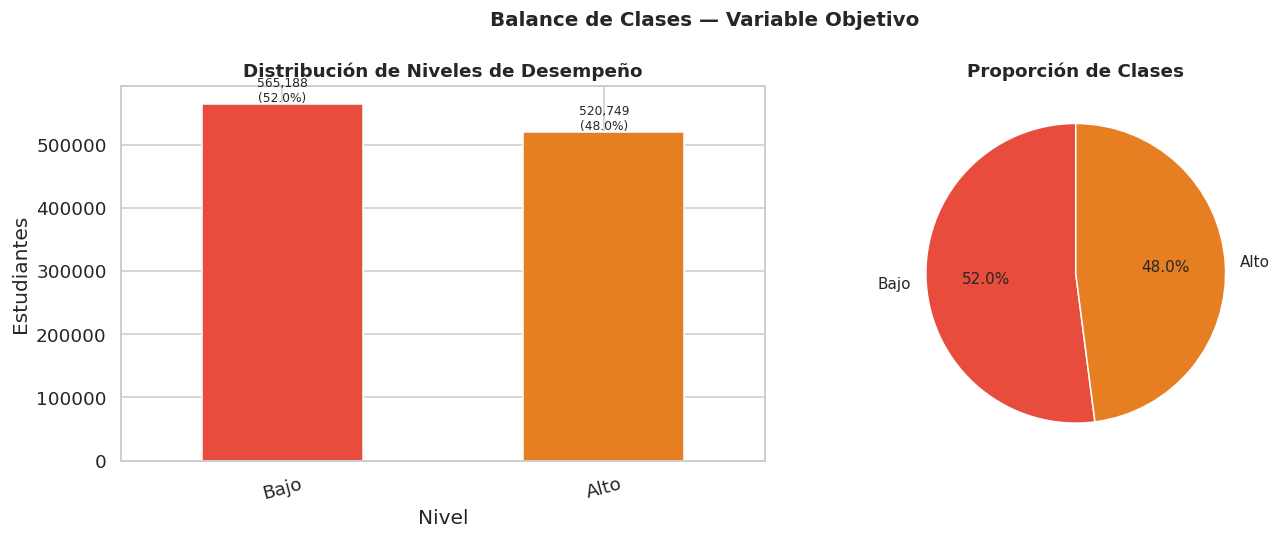

In [5]:
# ── Visualización del balance de clases ──────────────────────────────────────
#COLORES = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB']
COLORES = ['#E74C3C', '#E67E22', '#F1C40F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
dist.plot(kind='bar', ax=axes[0], color=COLORES, edgecolor='white')
axes[0].set_title('Distribución de Niveles de Desempeño',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Estudiantes')
axes[0].tick_params(axis='x', rotation=15)
total_p = dist.sum()
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_p * 0.003,
        f'{bar.get_height():,}\n({bar.get_height()/total_p*100:.1f}%)',
        ha='center', fontsize=8
    )

# Pie
dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
          colors=COLORES, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Balance de Clases — Variable Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_balance_clases.png', dpi=110, bbox_inches='tight')
plt.show()


In [6]:
# ── Definición de columnas ────────────────────────────────────────────────────
SCORE_COLS = [c for c in ['punt_ingles','punt_matematicas','punt_c_naturales',
                            'punt_sociales_ciudadanas','punt_lectura_critica','punt_global']
              if c in df_raw.columns]

EXCLUDE_COLS = SCORE_COLS + [
    'estu_consecutivo',
    'periodo',
    'nivel_desempeno',
    'cole_cod_depto_ubicacion',

    # =========================
    # Variables adicionales
    # =========================
    'estu_tipodocumento',
    'cole_cod_mcpio_ubicacion',
    'cole_cod_departamento_unicacion',
    'cole_codigo_icfes',
    'cole_nombre_establecimiento',
    'cole_nombre_sede',
    'estu_cod_depto_presentacion',
    'estu_cod_mcpio_presentacion',
    'estu_cod_reside_mcpio',
    'estu_fechanacimiento',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'estu_pais_reside',
    'desemp_ingles',
    'cole_mcpio_ubicacion',
    'cole_codigo_icfes',
    'cole_cod_dane_sede',
    'cole_cod_dane_establecimiento',
    'estu_cod_mcpio_presentacion'
]


TARGET       = 'nivel_desempeno'

# Excluir variables de alta cardinalidad (>200 categorías → problemas de memoria/encoding)
alta_card = []
for col in df.columns:
    if col not in EXCLUDE_COLS and df[col].dtype == object:
        if df[col].nunique() > 200:
            alta_card.append(col)
            EXCLUDE_COLS.append(col)

if alta_card:
    print(f'⚠️  Excluidas por alta cardinalidad (>{200} cat.): {alta_card}')

FEATURES     = [c for c in df.columns if c not in EXCLUDE_COLS]
NUM_FEATURES = df[FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df[FEATURES].select_dtypes(include=['object','category']).columns.tolist()

print(f'\nTotal features: {len(FEATURES)}')
print(f'  → Numéricas  : {len(NUM_FEATURES)} → {NUM_FEATURES}')
print(f'  → Categóricas: {len(CAT_FEATURES)} → {CAT_FEATURES}')



Total features: 26
  → Numéricas  : 0 → []
  → Categóricas: 26 → ['cole_area_ubicacion', 'cole_calendario', 'cole_caracter', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_sede_principal', 'estu_cod_reside_depto', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_genero', 'estu_nacionalidad', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'cole_bilingue']


### 5.3 Limpieza Pre-Modelado: Duplicados y Registros Sin Target

In [7]:
# ── Eliminar duplicados (estu_consecutivo) ────────────────────────────────────
n_antes = len(df)
df = df[~df.duplicated(subset=['estu_consecutivo'], keep='first')].reset_index(drop=True)
print(f'Registros eliminados por duplicado: {n_antes - len(df):,}')

# ── Eliminar filas sin nivel_desempeno (sin punt_global válido) ────────────────
df = df.dropna(subset=['nivel_desempeno']).reset_index(drop=True)
print(f'Registros con target válido: {len(df):,}')

# ── Codificación numérica del target ──────────────────────────────────────────
label2idx = {l: i for i, l in enumerate(LABELS)}
df['target'] = df['nivel_desempeno'].map(label2idx)

print('\nCodificación del target:')
for l, i in label2idx.items():
    print(f'  {i} → {l}')


Registros eliminados por duplicado: 533,096
Registros con target válido: 552,841

Codificación del target:
  0 → Bajo
  1 → Alto


## Para dos experimentos de eliminación e imputación

In [8]:
# ── Subsets por experimento ───────────────────────────────────────────────────
X_all = df[FEATURES].copy()
y_all = df['target'].copy()

# Experimento 1: solo filas completamente limpias
mask_clean = X_all.notna().all(axis=1)
X_exp1, y_exp1 = X_all[mask_clean].reset_index(drop=True), y_all[mask_clean].reset_index(drop=True)

# Experimento 2: dataset completo (con nulos — se imputará en el pipeline)
X_exp2, y_exp2 = X_all.copy(), y_all.copy()

print(f'Exp 1 (Eliminación): {len(X_exp1):,} registros ({len(X_exp1)/len(X_all)*100:.1f}%)')
print(f'Exp 2 (Imputación):  {len(X_exp2):,} registros ({len(X_exp2)/len(X_all)*100:.1f}%)')


Exp 1 (Eliminación): 406,448 registros (73.5%)
Exp 2 (Imputación):  552,841 registros (100.0%)


In [9]:
# ── División Train / Test estratificada (80/20) ────────────────────────────────
RANDOM_STATE = 42

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_exp1, y_exp1, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp1
)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_exp2, y_exp2, test_size=0.20, random_state=RANDOM_STATE, stratify=y_exp2
)

print('División Train / Test (80/20, estratificada):')
print(f'  Exp 1 → Train: {len(X_tr1):,}  |  Test: {len(X_te1):,}')
print(f'  Exp 2 → Train: {len(X_tr2):,}  |  Test: {len(X_te2):,}')


División Train / Test (80/20, estratificada):
  Exp 1 → Train: 325,158  |  Test: 81,290
  Exp 2 → Train: 442,272  |  Test: 110,569


In [10]:
# Experimento 1: sin imputación (datos ya limpios)
proc_e1 = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES)
], remainder='drop')

# Experimento 2: con imputación antes de escalar/codificar
proc_e2 = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), NUM_FEATURES),

    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore'))
    ]), CAT_FEATURES)

], remainder='drop')

print('✅ Preprocesadores definidos.')
print('  Exp 1: StandardScaler + OneHotEncoder (sin imputación)')
print('  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder')

✅ Preprocesadores definidos.
  Exp 1: StandardScaler + OneHotEncoder (sin imputación)
  Exp 2: SimpleImputer(median/moda) + StandardScaler + OneHotEncoder


In [11]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def evaluar(nombre, y_true, y_pred, y_prob=None, labels=None):
    """
    Calcula y muestra métricas completas de clasificación multiclase.

    Parámetros:
    -----------
    nombre  : str
    y_true  : array
    y_pred  : array
    y_prob  : array opcional (predict_proba)
    labels  : lista opcional de nombres de clases

    Retorna:
    --------
    dict con métricas
    """

    # ── Métricas principales ────────────────────────────────────────────────
    acc  = accuracy_score(y_true, y_pred)

    f1m  = f1_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    f1w  = f1_score(
        y_true, y_pred,
        average='weighted',
        zero_division=0
    )

    prec = precision_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    rec  = recall_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    # ── ROC AUC ─────────────────────────────────────────────────────────────
    auc = None

    if y_prob is not None:
        try:
            auc = roc_auc_score(
                y_true,
                y_prob,
                multi_class='ovr',
                average='macro'
            )
        except Exception as e:
            print(f'⚠️ No se pudo calcular ROC-AUC: {e}')

    # ── Mostrar métricas ────────────────────────────────────────────────────
    print(f'\n{"═"*58}')
    print(f'  {nombre}')
    print(f'{"═"*58}')

    print(f'  Accuracy            : {acc:.4f}')
    print(f'  F1-score (macro)    : {f1m:.4f}')
    print(f'  F1-score (weighted) : {f1w:.4f}')
    print(f'  Precision (macro)   : {prec:.4f}')
    print(f'  Recall (macro)      : {rec:.4f}')

    if auc is not None:
        print(f'  ROC-AUC (OvR macro) : {auc:.4f}')

    print()

    # ── Labels dinámicos ────────────────────────────────────────────────────
    if labels is None:
        labels = sorted(np.unique(y_true))

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[str(x) for x in labels],
            zero_division=0
        )
    )

    # ── Matriz de confusión ─────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.4
    )

    ax.set_title(
        f'Matriz de Confusión — {nombre}',
        fontsize=12,
        fontweight='bold',
        pad=10
    )

    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)

    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()

    fn = (
        f'images/fig_cm_'
        f'{nombre.replace(" ","_").replace("(","").replace(")","").lower()}.png'
    )

    plt.savefig(fn, dpi=110, bbox_inches='tight')

    plt.show()

    # ── Retorno ─────────────────────────────────────────────────────────────
    return {
        'modelo': nombre,
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'precision_macro': prec,
        'recall_macro': rec,
        'roc_auc': auc
    }


print('✅ Función evaluar() definida.')

✅ Función evaluar() definida.


## Aplicación de modelos

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import ParameterGrid
import numpy as np

print("GPU disponible:", tf.config.list_physical_devices('GPU'))

GPU disponible: []


W0000 00:00:1780033849.461565  245663 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [33]:
# ── Preparar datos para MLP — Exp 1 ──────────────────────────────────────────
proc_nn1 = clone(proc_e1)
Xtr_nn1  = proc_nn1.fit_transform(X_tr1)
Xte_nn1  = proc_nn1.transform(X_te1)

# Convertir a float32 y manejar NaNs (por si acaso)
Xtr_nn1 = np.nan_to_num(Xtr_nn1.astype(np.float32))
Xte_nn1 = np.nan_to_num(Xte_nn1.astype(np.float32))

N_FEAT = Xtr_nn1.shape[1]
print(f'✅ Datos preparados para MLP — Exp 1')
print(f'   Dimensión de entrada: {N_FEAT} features')
print(f'   Shape Xtr_nn1: {Xtr_nn1.shape}')
print(f'   Shape Xte_nn1: {Xte_nn1.shape}')


✅ Datos preparados para MLP — Exp 1
   Dimensión de entrada: 254 features
   Shape Xtr_nn1: (325158, 254)
   Shape Xte_nn1: (81290, 254)


# Experimentos Eliminación

## Experimento 1

In [49]:
# ── Arquitectura MLP ──────────────────────────────────────────────────────────
def build_mlp(n_features, n_classes=3, lr=1e-3):
    """
    Construye un MLP con:
      - Batch Normalization después de cada capa densa
      - Dropout para regularización
      - Salida Softmax (clasificación multiclase)
    """
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        # Normalización de la entrada
        layers.BatchNormalization(),

        # Bloque 1 — 1024 neuronas
        layers.Dense(1024, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 2 — 128 neuronas
        layers.Dense(512, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 3 — 64 neuronas
        layers.Dense(256, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.20),

        # Salida
        layers.Dense(n_classes, activation='softmax')
    ], name='MLP_Saber11')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp1 = build_mlp(N_FEAT)
mlp1.summary()


Model: "MLP_Saber11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_20          │ (None, 254)            │         1,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1024)           │       261,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 926,203 (3.53 MB)

 Trainable params: 922,111 (3.52 MB)

 Non-trainable params: 4,092 (15.98 KB)

In [50]:
# ── Entrenamiento MLP — Exp 1 ─────────────────────────────────────────────────
cw1 = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr1), y=y_tr1)
))
print(f'Class weights: {cw1}')

cb_es  = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

print('\n🚀 Entrenando MLP — Exp 1 (Eliminación)...')
hist1 = mlp1.fit(
    Xtr_nn1, y_tr1.values,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    class_weight=cw1,
    callbacks=[cb_es, cb_rlr],
    verbose=1
)


Class weights: {0: 1.0393548263362804, 1: 0.5493322520970072, 2: 4.598277544440202}

🚀 Entrenando MLP — Exp 1 (Eliminación)...
Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5086 - loss: 0.8624 - val_accuracy: 0.5328 - val_loss: 0.9249 - learning_rate: 0.0010
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5266 - loss: 0.8154 - val_accuracy: 0.5378 - val_loss: 0.9123 - learning_rate: 0.0010
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5320 - loss: 0.8052 - val_accuracy: 0.5455 - val_loss: 0.9032 - learning_rate: 0.0010
Epoch 4/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5368 - loss: 0.7962 - val_accuracy: 0.5455 - val_loss: 0.8991 - learning_rate: 0.0010
Epoch 5/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5401 - loss: 0.7860 - val_accuracy: 0.5403 - val_loss: 0.9003 - learning_rate: 0.0010
Epoch 6/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5451 - loss: 0.7729 - val_accuracy:

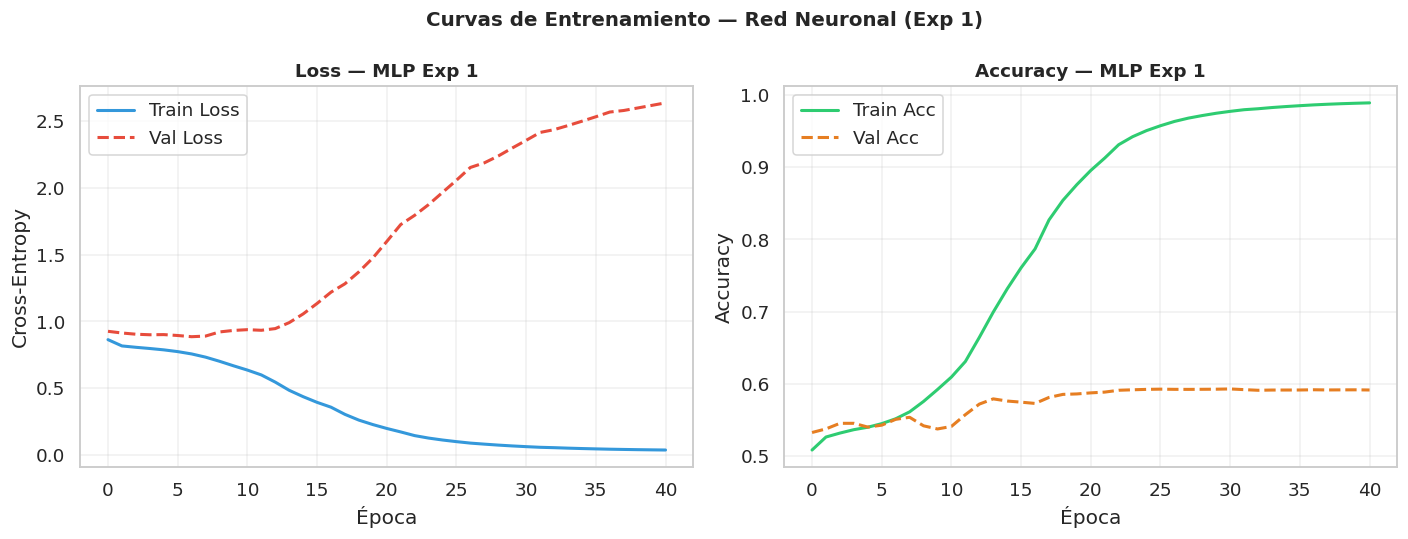

In [51]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1.history['loss'],     label='Train Loss', color='#3498DB', lw=2)
axes[0].plot(hist1.history['val_loss'], label='Val Loss',   color='#E74C3C', lw=2, ls='--')
axes[0].set_title('Loss — MLP Exp 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist1.history['accuracy'],     label='Train Acc', color='#2ECC71', lw=2)
axes[1].plot(hist1.history['val_accuracy'], label='Val Acc',   color='#E67E22', lw=2, ls='--')
axes[1].set_title('Accuracy — MLP Exp 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Red Neuronal (Exp 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_train_mlp_e1.png', dpi=110, bbox_inches='tight')
plt.show()


2541/2541 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

══════════════════════════════════════════════════════════
  MLP — Exp 1 (Elim.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.5915
  F1-score (macro)    : 0.4821
  F1-score (weighted) : 0.5883
  Precision (macro)   : 0.4913
  Recall (macro)      : 0.4753
  ROC-AUC (OvR macro) : 0.6860

              precision    recall  f1-score   support

        Bajo       0.49      0.49      0.49     26071
      Básico       0.67      0.69      0.68     49326
        Alto       0.31      0.25      0.28      5893

    accuracy                           0.59     81290
   macro avg       0.49      0.48      0.48     81290
weighted avg       0.59      0.59      0.59     81290



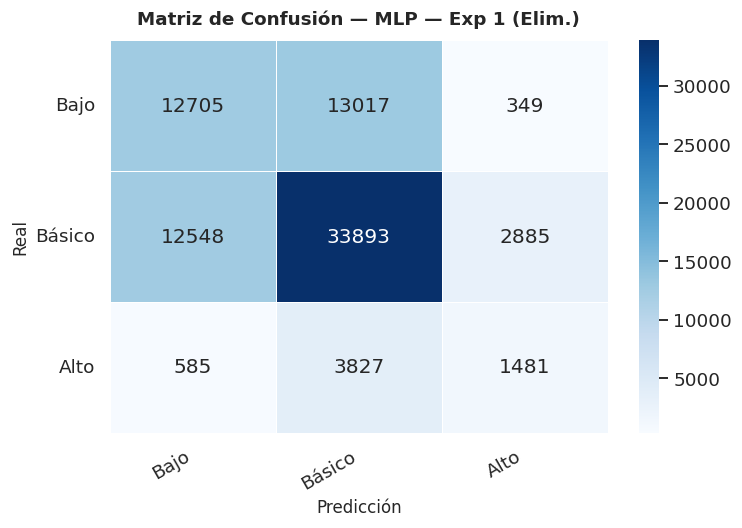

In [52]:
# ── Evaluación MLP — Exp 1 ───────────────────────────────────────────────────
ypr_nn1 = mlp1.predict(Xte_nn1)
yp_nn1  = np.argmax(ypr_nn1, axis=1)
met_nn1 = evaluar('MLP — Exp 1 (Elim.)', y_te1, yp_nn1, ypr_nn1, labels=['Bajo', 'Básico', 'Alto'])


## Experimento 2

In [53]:
# ── Arquitectura MLP ──────────────────────────────────────────────────────────
def build_mlp(n_features, n_classes=3, lr=1e-3):
    """
    Construye un MLP con:
      - Batch Normalization después de cada capa densa
      - Dropout para regularización
      - Salida Softmax (clasificación multiclase)
    """
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        # Normalización de la entrada
        layers.BatchNormalization(),

        # Bloque 1 — 1024 neuronas
        layers.Dense(128, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 2 — 128 neuronas
        layers.Dense(64, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 3 — 64 neuronas
        layers.Dense(32, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.20),

        # Salida
        layers.Dense(n_classes, activation='softmax')
    ], name='MLP_Saber11')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp1 = build_mlp(N_FEAT)
mlp1.summary()


Model: "MLP_Saber11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_24          │ (None, 254)            │         1,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,987 (175.73 KB)

 Trainable params: 44,031 (172.00 KB)

 Non-trainable params: 956 (3.73 KB)

In [54]:
# ── Entrenamiento MLP — Exp 2 ─────────────────────────────────────────────────
cw1 = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr1), y=y_tr1)
))
print(f'Class weights: {cw1}')

cb_es  = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

print('\n🚀 Entrenando MLP — Exp 1 (Eliminación)...')
hist1 = mlp1.fit(
    Xtr_nn1, y_tr1.values,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    class_weight=cw1,
    callbacks=[cb_es, cb_rlr],
    verbose=1
)


Class weights: {0: 1.0393548263362804, 1: 0.5493322520970072, 2: 4.598277544440202}

🚀 Entrenando MLP — Exp 1 (Eliminación)...
Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5030 - loss: 0.8629 - val_accuracy: 0.5266 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5282 - loss: 0.8182 - val_accuracy: 0.5347 - val_loss: 0.9037 - learning_rate: 0.0010
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5313 - loss: 0.8094 - val_accuracy: 0.5307 - val_loss: 0.9047 - learning_rate: 0.0010
Epoch 4/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5339 - loss: 0.8031 - val_accuracy: 0.5344 - val_loss: 0.8975 - learning_rate: 0.0010
Epoch 5/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5350 - loss: 0.7978 - val_accuracy: 0.5368 - val_loss: 0.8960 - learning_rate: 0.0010
Epoch 6/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5370 - loss: 0.7928 - val_accuracy: 0.538

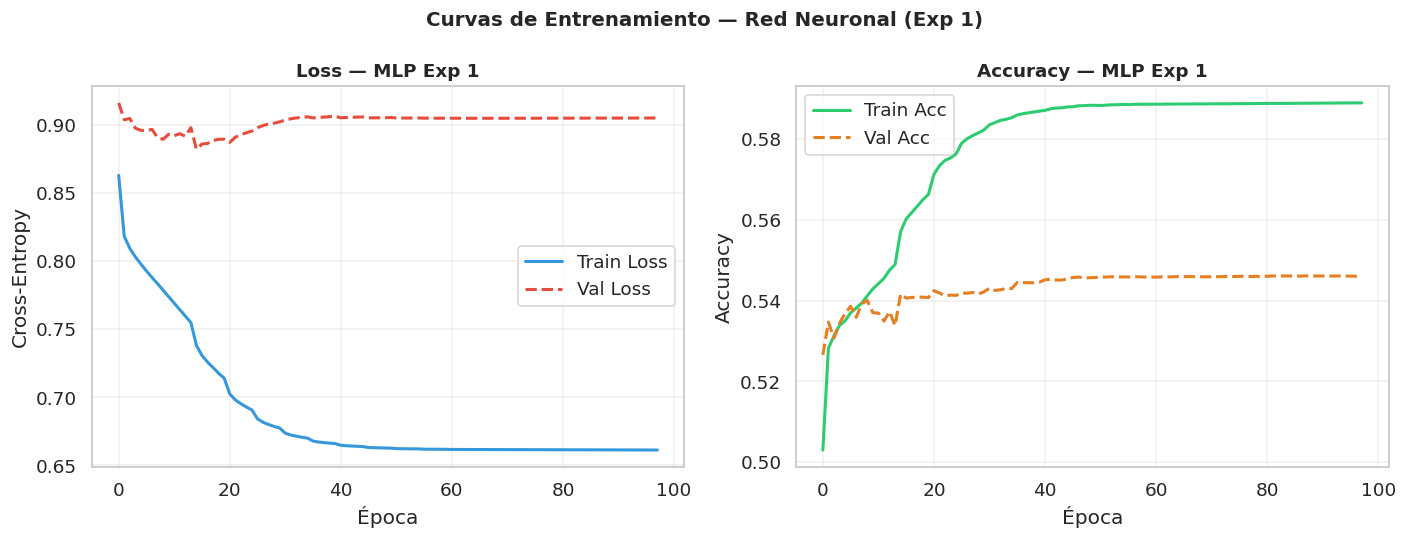

In [55]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1.history['loss'],     label='Train Loss', color='#3498DB', lw=2)
axes[0].plot(hist1.history['val_loss'], label='Val Loss',   color='#E74C3C', lw=2, ls='--')
axes[0].set_title('Loss — MLP Exp 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist1.history['accuracy'],     label='Train Acc', color='#2ECC71', lw=2)
axes[1].plot(hist1.history['val_accuracy'], label='Val Acc',   color='#E67E22', lw=2, ls='--')
axes[1].set_title('Accuracy — MLP Exp 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Red Neuronal (Exp 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_train_mlp_e1.png', dpi=110, bbox_inches='tight')
plt.show()


2541/2541 ━━━━━━━━━━━━━━━━━━━━ 2s 634us/step

══════════════════════════════════════════════════════════
  MLP — Exp 1 (Elim.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.5462
  F1-score (macro)    : 0.4964
  F1-score (weighted) : 0.5619
  Precision (macro)   : 0.4911
  Recall (macro)      : 0.5823
  ROC-AUC (OvR macro) : 0.7381

              precision    recall  f1-score   support

        Bajo       0.53      0.65      0.59     26071
      Básico       0.72      0.48      0.58     49326
        Alto       0.22      0.61      0.33      5893

    accuracy                           0.55     81290
   macro avg       0.49      0.58      0.50     81290
weighted avg       0.62      0.55      0.56     81290



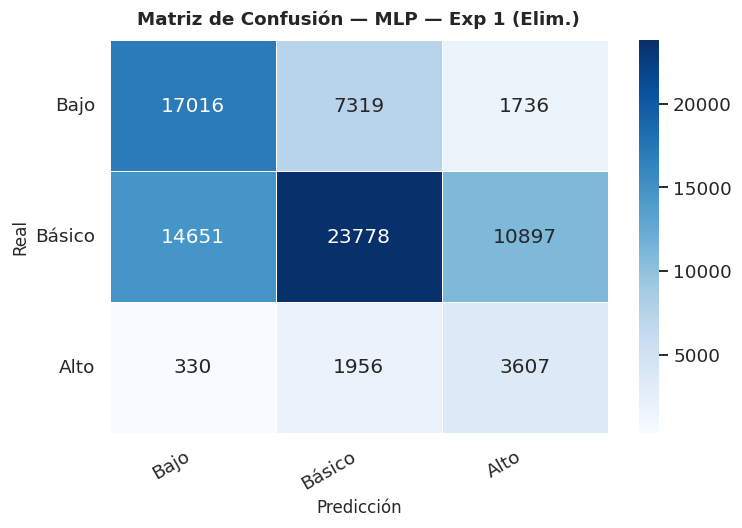

In [56]:
# ── Evaluación MLP — Exp 1 ───────────────────────────────────────────────────
ypr_nn1 = mlp1.predict(Xte_nn1)
yp_nn1  = np.argmax(ypr_nn1, axis=1)
met_nn1 = evaluar('MLP — Exp 1 (Elim.)', y_te1, yp_nn1, ypr_nn1, labels=['Bajo', 'Básico', 'Alto'])


## Experimento 3

In [60]:
# ── Arquitectura MLP ──────────────────────────────────────────────────────────
def build_mlp(n_features, n_classes=3, lr=1e-3):
    """
    Construye un MLP con:
      - Batch Normalization después de cada capa densa
      - Dropout para regularización
      - Salida Softmax (clasificación multiclase)
    """
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        # Normalización de la entrada
        layers.BatchNormalization(),

        # Bloque 1 — 1024 neuronas
        layers.Dense(512, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 2 — 128 neuronas
        layers.Dense(1024, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 3 — 64 neuronas
        layers.Dense(64, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.20),

        # Salida
        layers.Dense(n_classes, activation='softmax')
    ], name='MLP_Saber11')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp1 = build_mlp(N_FEAT)
mlp1.summary()


Model: "MLP_Saber11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_28          │ (None, 254)            │         1,016 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 512)            │       130,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 729,083 (2.78 MB)

 Trainable params: 725,375 (2.77 MB)

 Non-trainable params: 3,708 (14.48 KB)

In [61]:
# ── Entrenamiento MLP — Exp 3 ─────────────────────────────────────────────────
cw1 = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr1), y=y_tr1)
))
print(f'Class weights: {cw1}')

cb_es  = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

print('\n🚀 Entrenando MLP — Exp 1 (Eliminación)...')
hist1 = mlp1.fit(
    Xtr_nn1, y_tr1.values,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    class_weight=cw1,
    callbacks=[cb_es, cb_rlr],
    verbose=1
)


Class weights: {0: 1.0393548263362804, 1: 0.5493322520970072, 2: 4.598277544440202}

🚀 Entrenando MLP — Exp 1 (Eliminación)...
Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5070 - loss: 0.8483 - val_accuracy: 0.5318 - val_loss: 0.9129 - learning_rate: 0.0010
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5267 - loss: 0.8141 - val_accuracy: 0.5330 - val_loss: 0.9066 - learning_rate: 0.0010
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5317 - loss: 0.8042 - val_accuracy: 0.5379 - val_loss: 0.9000 - learning_rate: 0.0010
Epoch 4/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5356 - loss: 0.7950 - val_accuracy: 0.5316 - val_loss: 0.9028 - learning_rate: 0.0010
Epoch 5/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5393 - loss: 0.7853 - val_accuracy: 0.5348 - val_loss: 0.8993 - learning_rate: 0.0010
Epoch 6/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5444 - loss: 0.7731 - val_accuracy:

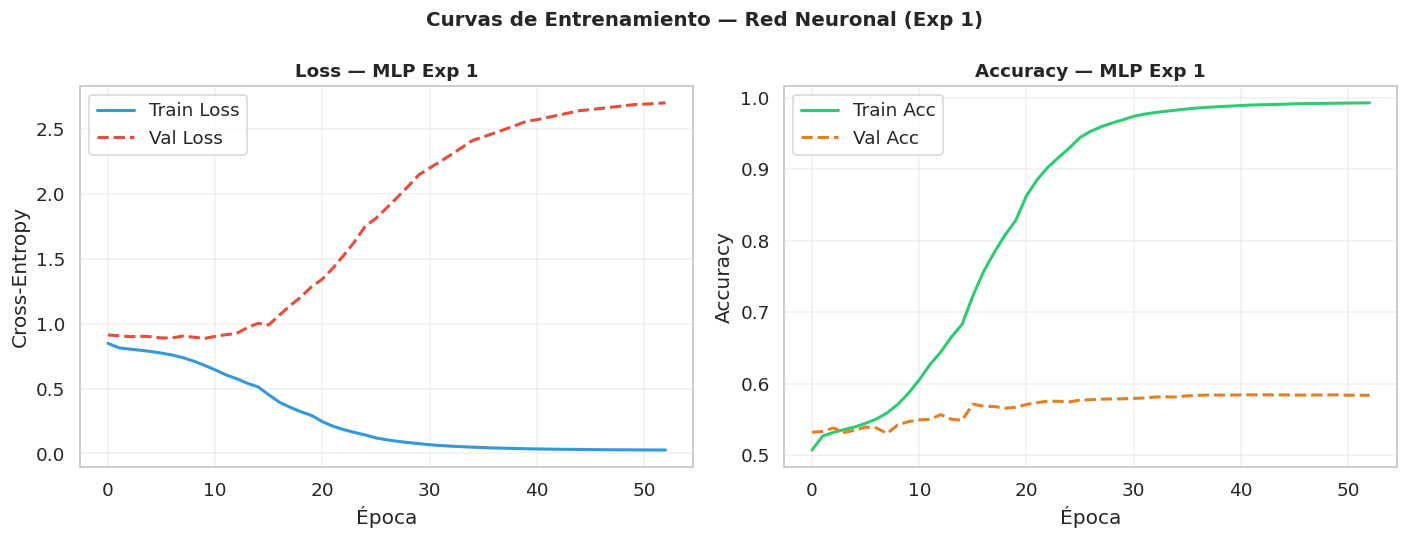

In [64]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1.history['loss'],     label='Train Loss', color='#3498DB', lw=2)
axes[0].plot(hist1.history['val_loss'], label='Val Loss',   color='#E74C3C', lw=2, ls='--')
axes[0].set_title('Loss — MLP Exp 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist1.history['accuracy'],     label='Train Acc', color='#2ECC71', lw=2)
axes[1].plot(hist1.history['val_accuracy'], label='Val Acc',   color='#E67E22', lw=2, ls='--')
axes[1].set_title('Accuracy — MLP Exp 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Red Neuronal (Exp 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_train_mlp_e1.png', dpi=110, bbox_inches='tight')
plt.show()


2541/2541 ━━━━━━━━━━━━━━━━━━━━ 2s 868us/step

══════════════════════════════════════════════════════════
  MLP — Exp 1 (Elim.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.5850
  F1-score (macro)    : 0.4761
  F1-score (weighted) : 0.5828
  Precision (macro)   : 0.4892
  Recall (macro)      : 0.4689
  ROC-AUC (OvR macro) : 0.6803

              precision    recall  f1-score   support

        Bajo       0.48      0.52      0.50     26071
      Básico       0.67      0.66      0.67     49326
        Alto       0.32      0.23      0.27      5893

    accuracy                           0.58     81290
   macro avg       0.49      0.47      0.48     81290
weighted avg       0.58      0.58      0.58     81290



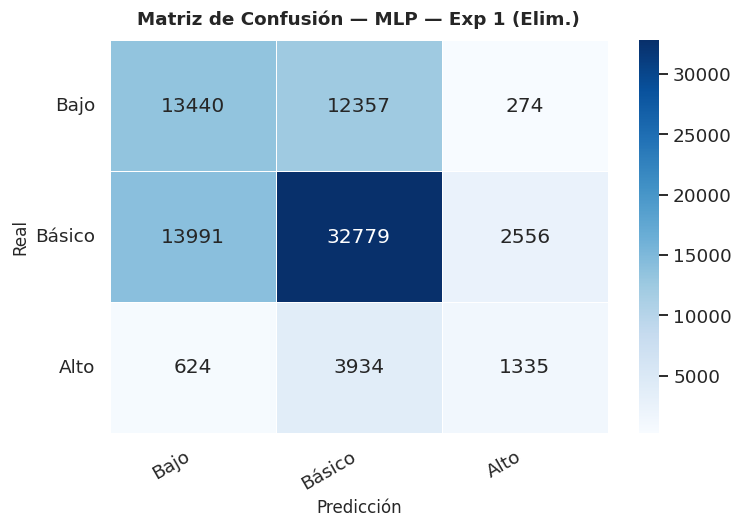

In [65]:
# ── Evaluación MLP — Exp 1 ───────────────────────────────────────────────────
ypr_nn1 = mlp1.predict(Xte_nn1)
yp_nn1  = np.argmax(ypr_nn1, axis=1)
met_nn1 = evaluar('MLP — Exp 1 (Elim.)', y_te1, yp_nn1, ypr_nn1, labels=['Bajo', 'Básico', 'Alto'])


## Resultados experimentos con eliminación

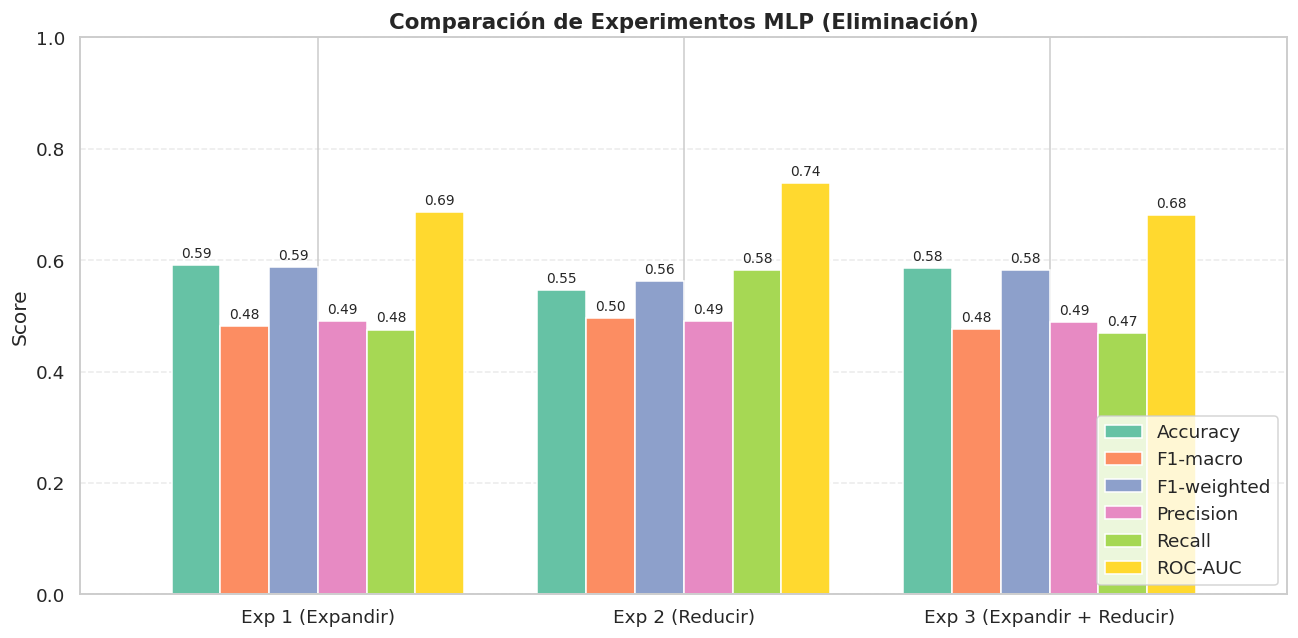

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_experiments_metrics():
    data = {
        "Exp 1 (Expandir)": {
            "Accuracy": 0.5915,
            "F1-macro": 0.4821,
            "F1-weighted": 0.5883,
            "Precision": 0.4913,
            "Recall": 0.4753,
            "ROC-AUC": 0.6860
        },
        "Exp 2 (Reducir)": {
            "Accuracy": 0.5462,
            "F1-macro": 0.4964,
            "F1-weighted": 0.5619,
            "Precision": 0.4911,
            "Recall": 0.5823,
            "ROC-AUC": 0.7381
        },
        "Exp 3 (Expandir + Reducir)": {
            "Accuracy": 0.5850,
            "F1-macro": 0.4761,
            "F1-weighted": 0.5828,
            "Precision": 0.4892,
            "Recall": 0.4689,
            "ROC-AUC": 0.6803
        }
    }

    df = pd.DataFrame(data).T

    ax = df.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8
    )

    ax.set_title("Comparación de Experimentos MLP (Eliminación)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=0)
    plt.legend(loc="lower right")

    # ── Añadir valores encima de las barras ───────────────
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

    plt.tight_layout()
    plt.show()


plot_experiments_metrics()

# Experimentos inputación

In [13]:
# ── Preparar datos MLP — Exp 2 ───────────────────────────────────────────────
proc_nn2 = clone(proc_e2)
Xtr_nn2  = proc_nn2.fit_transform(X_tr2)
Xte_nn2  = proc_nn2.transform(X_te2)

if hasattr(Xtr_nn2, 'toarray'):
    Xtr_nn2, Xte_nn2 = Xtr_nn2.toarray(), Xte_nn2.toarray()
Xtr_nn2 = np.nan_to_num(Xtr_nn2.astype(np.float32))
Xte_nn2 = np.nan_to_num(Xte_nn2.astype(np.float32))

N_FEAT2 = Xtr_nn2.shape[1]
print(f'✅ Datos preparados para MLP — Exp 2')
print(f'   Dimensión de entrada: {N_FEAT2} features')
print(f'   Shape Xtr_nn1: {Xtr_nn2.shape}')
print(f'   Shape Xte_nn1: {Xte_nn2.shape}')

✅ Datos preparados para MLP — Exp 2
   Dimensión de entrada: 275 features
   Shape Xtr_nn1: (442272, 275)
   Shape Xte_nn1: (110569, 275)


## Experimento 1

In [70]:
# ── Arquitectura MLP ──────────────────────────────────────────────────────────
def build_mlp(n_features, n_classes=3, lr=1e-3):
    """
    Construye un MLP con:
      - Batch Normalization después de cada capa densa
      - Dropout para regularización
      - Salida Softmax (clasificación multiclase)
    """
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        # Normalización de la entrada
        layers.BatchNormalization(),

        # Bloque 1 — 1024 neuronas
        layers.Dense(1024, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 2 — 128 neuronas
        layers.Dense(512, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 3 — 64 neuronas
        layers.Dense(256, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.20),

        # Salida
        layers.Dense(n_classes, activation='softmax')
    ], name='MLP_Saber11')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp1 = build_mlp(N_FEAT2)
mlp1.summary()


Model: "MLP_Saber11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_36          │ (None, 283)            │         1,132 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1024)           │       290,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956,015 (3.65 MB)

 Trainable params: 951,865 (3.63 MB)

 Non-trainable params: 4,150 (16.21 KB)

In [77]:
# ── Entrenamiento MLP — Exp 1 ─────────────────────────────────────────────────
cw2 = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
))
print(f'Class weights: {cw2}')

cb_es  = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

print('\n🚀 Entrenando MLP — Exp 1 (Imputación)...')
hist1 = mlp1.fit(
    Xtr_nn2, y_tr2.values,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    class_weight=cw2,
    callbacks=[cb_es, cb_rlr],
    verbose=1
)


Class weights: {0: 0.9499152689807149, 1: 0.5711562675551595, 2: 5.09060773480663}

🚀 Entrenando MLP — Exp 1 (Imputación)...
Epoch 1/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6312 - loss: 0.5993 - val_accuracy: 0.5806 - val_loss: 0.8764 - learning_rate: 0.0010
Epoch 2/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6477 - loss: 0.5707 - val_accuracy: 0.5912 - val_loss: 0.8849 - learning_rate: 0.0010
Epoch 3/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6639 - loss: 0.5445 - val_accuracy: 0.5973 - val_loss: 0.8989 - learning_rate: 0.0010
Epoch 4/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6784 - loss: 0.5199 - val_accuracy: 0.5964 - val_loss: 0.9258 - learning_rate: 0.0010
Epoch 5/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6946 - loss: 0.4977 - val_accuracy: 0.5922 - val_loss: 0.9614 - learning_rate: 0.0010
Epoch 6/100
733/735 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7094 - loss: 0.4743
Epoch 6: ReduceLR

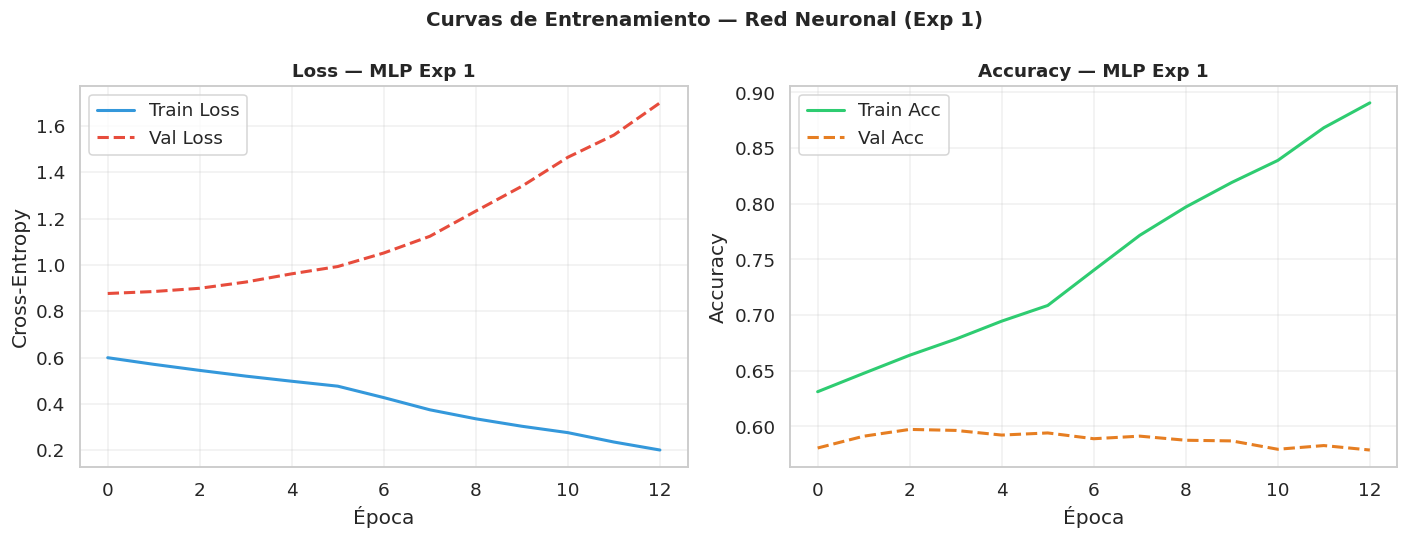

In [78]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1.history['loss'],     label='Train Loss', color='#3498DB', lw=2)
axes[0].plot(hist1.history['val_loss'], label='Val Loss',   color='#E74C3C', lw=2, ls='--')
axes[0].set_title('Loss — MLP Exp 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist1.history['accuracy'],     label='Train Acc', color='#2ECC71', lw=2)
axes[1].plot(hist1.history['val_accuracy'], label='Val Acc',   color='#E67E22', lw=2, ls='--')
axes[1].set_title('Accuracy — MLP Exp 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Red Neuronal (Exp 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_train_mlp_e1.png', dpi=110, bbox_inches='tight')
plt.show()


3456/3456 ━━━━━━━━━━━━━━━━━━━━ 3s 796us/step

══════════════════════════════════════════════════════════
  MLP — Exp 1 (inpu.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.6017
  F1-score (macro)    : 0.5214
  F1-score (weighted) : 0.6086
  Precision (macro)   : 0.5084
  Recall (macro)      : 0.5473
  ROC-AUC (OvR macro) : 0.7379

              precision    recall  f1-score   support

        Bajo       0.57      0.62      0.59     38800
      Básico       0.69      0.61      0.65     64529
        Alto       0.26      0.41      0.32      7240

    accuracy                           0.60    110569
   macro avg       0.51      0.55      0.52    110569
weighted avg       0.62      0.60      0.61    110569



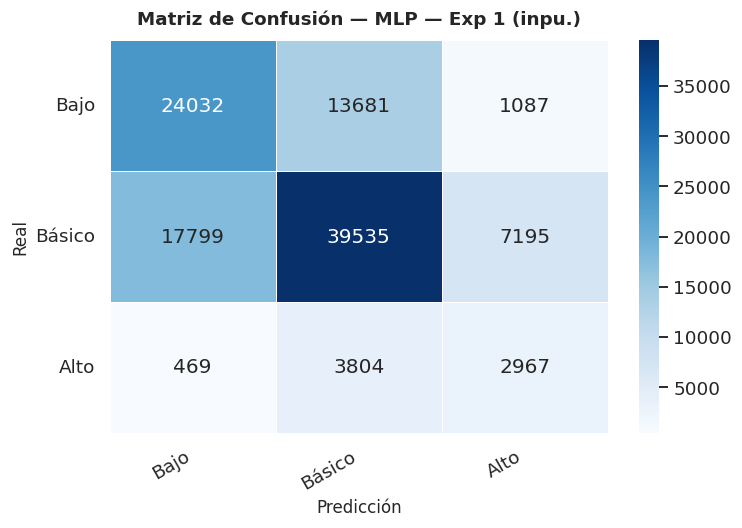

In [80]:
# ── Evaluación MLP — Exp 1 ───────────────────────────────────────────────────
ypr_nn2 = mlp1.predict(Xte_nn2)
yp_nn2  = np.argmax(ypr_nn2, axis=1)
met_nn2 = evaluar('MLP — Exp 1 (inpu.)', y_te2, yp_nn2, ypr_nn2, labels=['Bajo', 'Básico', 'Alto'])


## Experimento 2

In [81]:
# ── Arquitectura MLP ──────────────────────────────────────────────────────────
def build_mlp(n_features, n_classes=3, lr=1e-3):
    """
    Construye un MLP con:
      - Batch Normalization después de cada capa densa
      - Dropout para regularización
      - Salida Softmax (clasificación multiclase)
    """
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        # Normalización de la entrada
        layers.BatchNormalization(),

        # Bloque 1 — 1024 neuronas
        layers.Dense(128, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 2 — 128 neuronas
        layers.Dense(64, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 3 — 64 neuronas
        layers.Dense(32, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.20),

        # Salida
        layers.Dense(n_classes, activation='softmax')
    ], name='MLP_Saber11')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp1 = build_mlp(N_FEAT2)
mlp1.summary()


Model: "MLP_Saber11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_40          │ (None, 283)            │         1,132 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,815 (190.68 KB)

 Trainable params: 47,801 (186.72 KB)

 Non-trainable params: 1,014 (3.96 KB)

In [82]:
# ── Entrenamiento MLP — Exp 1 ─────────────────────────────────────────────────
cw2 = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
))
print(f'Class weights: {cw2}')

cb_es  = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

print('\n🚀 Entrenando MLP — Exp 2 (Imputación)...')
hist1 = mlp1.fit(
    Xtr_nn2, y_tr2.values,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    class_weight=cw2,
    callbacks=[cb_es, cb_rlr],
    verbose=1
)


Class weights: {0: 0.9499152689807149, 1: 0.5711562675551595, 2: 5.09060773480663}

🚀 Entrenando MLP — Exp 2 (Imputación)...
Epoch 1/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5190 - loss: 0.8496 - val_accuracy: 0.5318 - val_loss: 0.9000 - learning_rate: 0.0010
Epoch 2/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5370 - loss: 0.8074 - val_accuracy: 0.5360 - val_loss: 0.8901 - learning_rate: 0.0010
Epoch 3/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5404 - loss: 0.7988 - val_accuracy: 0.5412 - val_loss: 0.8827 - learning_rate: 0.0010
Epoch 4/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5425 - loss: 0.7925 - val_accuracy: 0.5442 - val_loss: 0.8784 - learning_rate: 0.0010
Epoch 5/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5441 - loss: 0.7873 - val_accuracy: 0.5410 - val_loss: 0.8771 - learning_rate: 0.0010
Epoch 6/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5454 - loss: 0.7820 - val_accuracy: 0.5468 

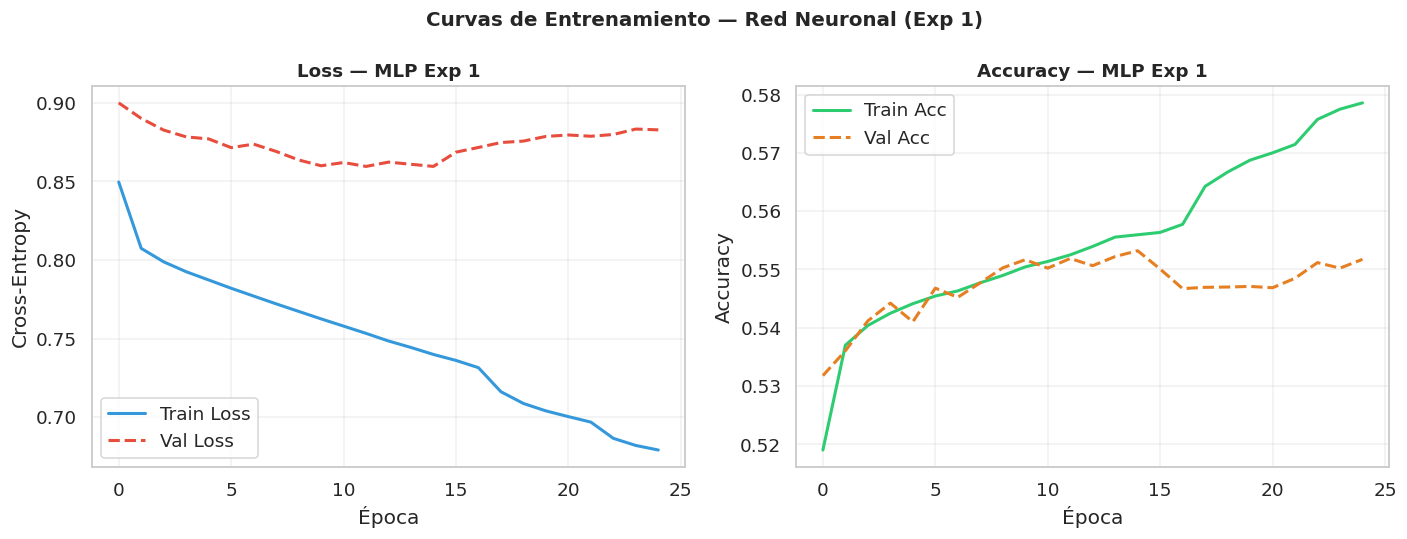

In [84]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1.history['loss'],     label='Train Loss', color='#3498DB', lw=2)
axes[0].plot(hist1.history['val_loss'], label='Val Loss',   color='#E74C3C', lw=2, ls='--')
axes[0].set_title('Loss — MLP Exp 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist1.history['accuracy'],     label='Train Acc', color='#2ECC71', lw=2)
axes[1].plot(hist1.history['val_accuracy'], label='Val Acc',   color='#E67E22', lw=2, ls='--')
axes[1].set_title('Accuracy — MLP Exp 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Red Neuronal (Exp 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_train_mlp_e1.png', dpi=110, bbox_inches='tight')
plt.show()


3456/3456 ━━━━━━━━━━━━━━━━━━━━ 1s 406us/step

══════════════════════════════════════════════════════════
  MLP — Exp 2 (inpu.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.5567
  F1-score (macro)    : 0.5047
  F1-score (weighted) : 0.5739
  Precision (macro)   : 0.5016
  Recall (macro)      : 0.6029
  ROC-AUC (OvR macro) : 0.7565

              precision    recall  f1-score   support

        Bajo       0.59      0.66      0.62     38800
      Básico       0.71      0.48      0.57     64529
        Alto       0.21      0.67      0.32      7240

    accuracy                           0.56    110569
   macro avg       0.50      0.60      0.50    110569
weighted avg       0.63      0.56      0.57    110569



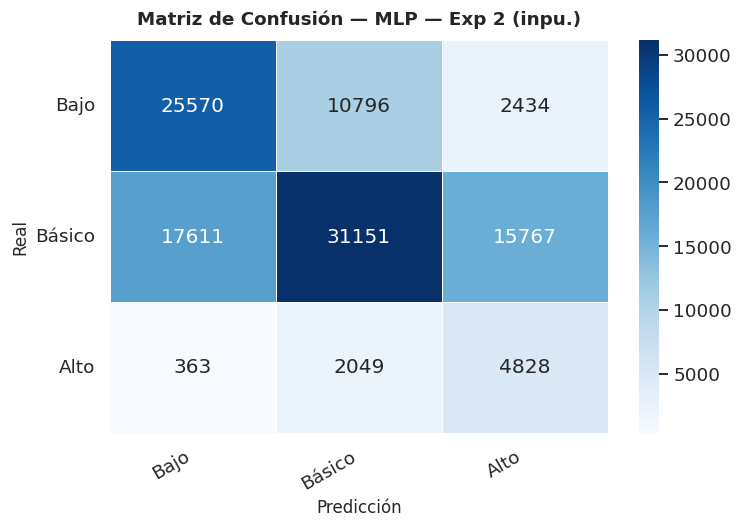

In [83]:
# ── Evaluación MLP — Exp 1 ───────────────────────────────────────────────────
ypr_nn2 = mlp1.predict(Xte_nn2)
yp_nn2  = np.argmax(ypr_nn2, axis=1)
met_nn2 = evaluar('MLP — Exp 2 (inpu.)', y_te2, yp_nn2, ypr_nn2, labels=['Bajo', 'Básico', 'Alto'])


## Experimento 3

In [85]:
# ── Arquitectura MLP ──────────────────────────────────────────────────────────
def build_mlp(n_features, n_classes=3, lr=1e-3):
    """
    Construye un MLP con:
      - Batch Normalization después de cada capa densa
      - Dropout para regularización
      - Salida Softmax (clasificación multiclase)
    """
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        # Normalización de la entrada
        layers.BatchNormalization(),

        # Bloque 1 — 1024 neuronas
        layers.Dense(512, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 2 — 128 neuronas
        layers.Dense(1024, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 3 — 64 neuronas
        layers.Dense(64, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.20),

        # Salida
        layers.Dense(n_classes, activation='softmax')
    ], name='MLP_Saber11')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp1 = build_mlp(N_FEAT2)
mlp1.summary()


Model: "MLP_Saber11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_44          │ (None, 283)            │         1,132 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 512)            │       145,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 744,047 (2.84 MB)

 Trainable params: 740,281 (2.82 MB)

 Non-trainable params: 3,766 (14.71 KB)

In [87]:
# ── Entrenamiento MLP — Exp 1 ─────────────────────────────────────────────────
cw2 = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
))
print(f'Class weights: {cw2}')

cb_es  = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

print('\n🚀 Entrenando MLP — Exp 3 (Imputación)...')
hist1 = mlp1.fit(
    Xtr_nn2, y_tr2.values,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    class_weight=cw2,
    callbacks=[cb_es, cb_rlr],
    verbose=1
)


Class weights: {0: 0.9499152689807149, 1: 0.5711562675551595, 2: 5.09060773480663}

🚀 Entrenando MLP — Exp 3 (Imputación)...
Epoch 1/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5338 - loss: 0.8129 - val_accuracy: 0.5389 - val_loss: 0.8850 - learning_rate: 0.0010
Epoch 2/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5407 - loss: 0.7989 - val_accuracy: 0.5444 - val_loss: 0.8770 - learning_rate: 0.0010
Epoch 3/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5436 - loss: 0.7896 - val_accuracy: 0.5514 - val_loss: 0.8699 - learning_rate: 0.0010
Epoch 4/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5474 - loss: 0.7804 - val_accuracy: 0.5518 - val_loss: 0.8651 - learning_rate: 0.0010
Epoch 5/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5509 - loss: 0.7698 - val_accuracy: 0.5551 - val_loss: 0.8556 - learning_rate: 0.0010
Epoch 6/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5553 - loss: 0.7566 - val_accuracy: 0.5650

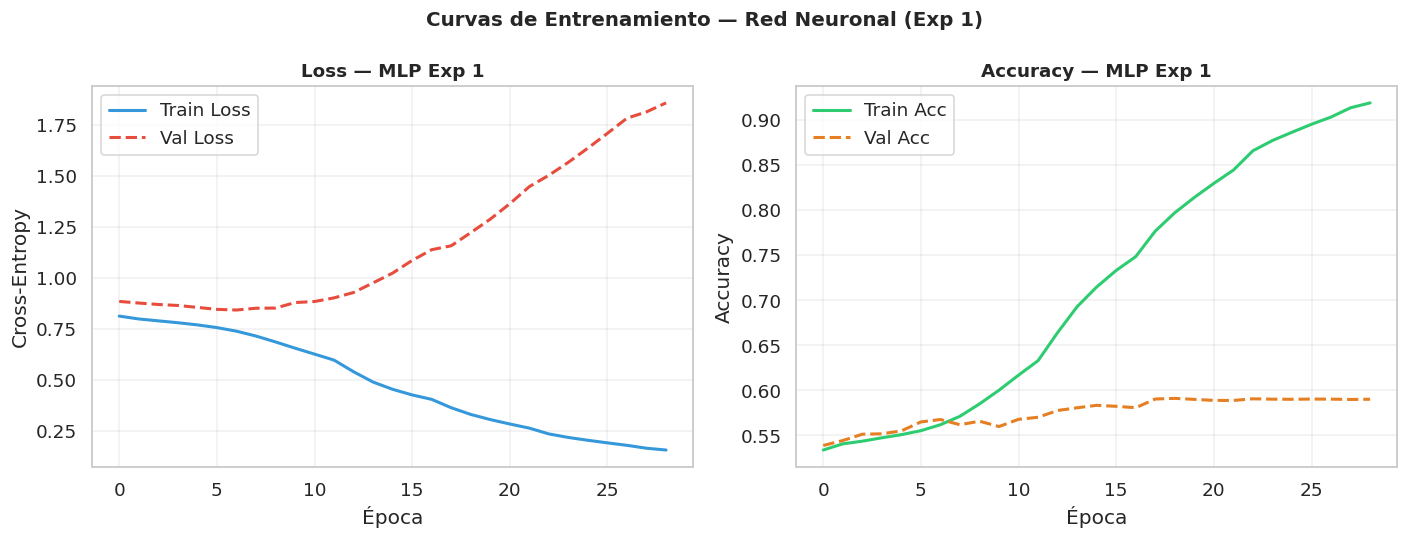

In [88]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1.history['loss'],     label='Train Loss', color='#3498DB', lw=2)
axes[0].plot(hist1.history['val_loss'], label='Val Loss',   color='#E74C3C', lw=2, ls='--')
axes[0].set_title('Loss — MLP Exp 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist1.history['accuracy'],     label='Train Acc', color='#2ECC71', lw=2)
axes[1].plot(hist1.history['val_accuracy'], label='Val Acc',   color='#E67E22', lw=2, ls='--')
axes[1].set_title('Accuracy — MLP Exp 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Red Neuronal (Exp 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_train_mlp_e1.png', dpi=110, bbox_inches='tight')
plt.show()


3456/3456 ━━━━━━━━━━━━━━━━━━━━ 2s 650us/step

══════════════════════════════════════════════════════════
  MLP — Exp 3 (inpu.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.5924
  F1-score (macro)    : 0.5109
  F1-score (weighted) : 0.5964
  Precision (macro)   : 0.5016
  Recall (macro)      : 0.5246
  ROC-AUC (OvR macro) : 0.7152

              precision    recall  f1-score   support

        Bajo       0.54      0.58      0.56     38800
      Básico       0.67      0.63      0.65     64529
        Alto       0.29      0.37      0.32      7240

    accuracy                           0.59    110569
   macro avg       0.50      0.52      0.51    110569
weighted avg       0.60      0.59      0.60    110569



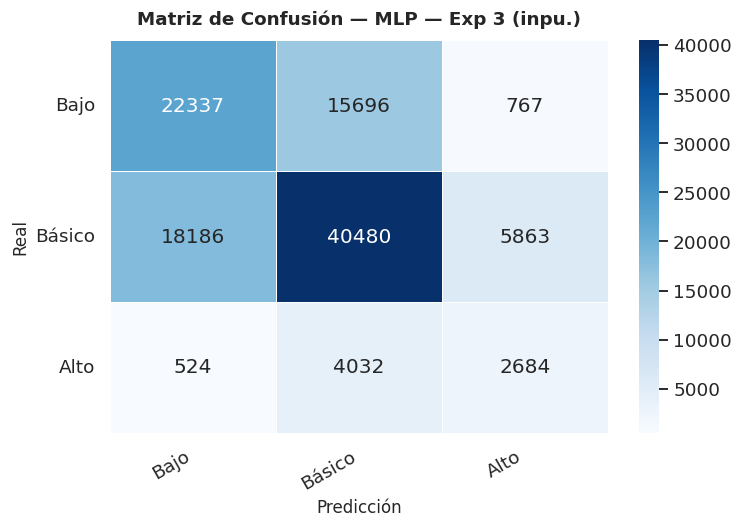

In [89]:
# ── Evaluación MLP — Exp 1 ───────────────────────────────────────────────────
ypr_nn2 = mlp1.predict(Xte_nn2)
yp_nn2  = np.argmax(ypr_nn2, axis=1)
met_nn2 = evaluar('MLP — Exp 3 (inpu.)', y_te2, yp_nn2, ypr_nn2, labels=['Bajo', 'Básico', 'Alto'])


## Resultados experimentos con imptación

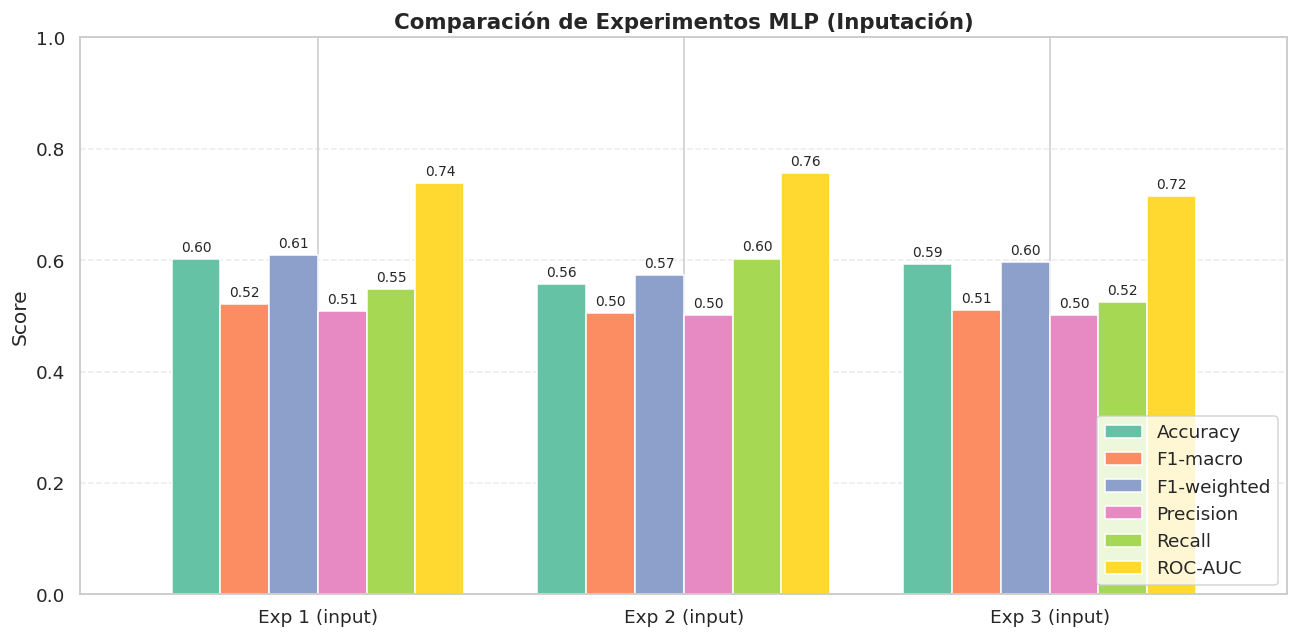

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_experiments_metrics_inpu():
    data = {
        "Exp 1 (input)": {
            "Accuracy": 0.6017,
            "F1-macro": 0.5214,
            "F1-weighted": 0.6086,
            "Precision": 0.5084,
            "Recall": 0.5473,
            "ROC-AUC": 0.7379
        },
        "Exp 2 (input)": {
            "Accuracy": 0.5567,
            "F1-macro": 0.5047,
            "F1-weighted": 0.5739,
            "Precision": 0.5016,
            "Recall": 0.6029,
            "ROC-AUC": 0.7565
        },
        "Exp 3 (input)": {
            "Accuracy": 0.5924,
            "F1-macro": 0.5109,
            "F1-weighted": 0.5964,
            "Precision": 0.5016,
            "Recall": 0.5246,
            "ROC-AUC": 0.7152
        }
    }

    df = pd.DataFrame(data).T

    ax = df.plot(
        kind="bar",
        figsize=(12, 6),
        width=0.8
    )

    ax.set_title("Comparación de Experimentos MLP (Inputación)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.xticks(rotation=0)
    plt.legend(loc="lower right")

    # ── valores sobre barras ─────────────────────────────
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

    plt.tight_layout()
    plt.show()


plot_experiments_metrics_inpu()

# Resultados con tag 3

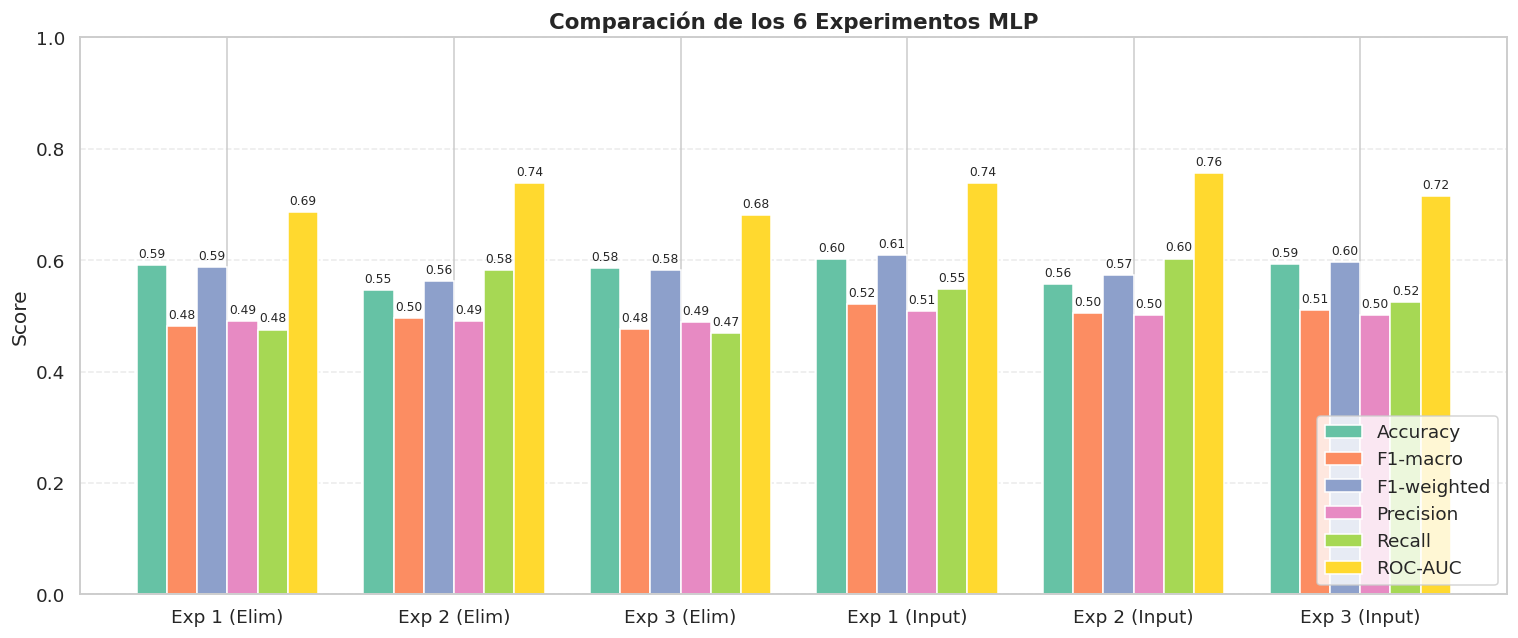

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_experiments():

    data = {
        "Exp 1 (Elim)": {
            "Accuracy": 0.5915,
            "F1-macro": 0.4821,
            "F1-weighted": 0.5883,
            "Precision": 0.4913,
            "Recall": 0.4753,
            "ROC-AUC": 0.6860
        },
        "Exp 2 (Elim)": {
            "Accuracy": 0.5462,
            "F1-macro": 0.4964,
            "F1-weighted": 0.5619,
            "Precision": 0.4911,
            "Recall": 0.5823,
            "ROC-AUC": 0.7381
        },
        "Exp 3 (Elim)": {
            "Accuracy": 0.5850,
            "F1-macro": 0.4761,
            "F1-weighted": 0.5828,
            "Precision": 0.4892,
            "Recall": 0.4689,
            "ROC-AUC": 0.6803
        },
        "Exp 1 (Input)": {
            "Accuracy": 0.6017,
            "F1-macro": 0.5214,
            "F1-weighted": 0.6086,
            "Precision": 0.5084,
            "Recall": 0.5473,
            "ROC-AUC": 0.7379
        },
        "Exp 2 (Input)": {
            "Accuracy": 0.5567,
            "F1-macro": 0.5047,
            "F1-weighted": 0.5739,
            "Precision": 0.5016,
            "Recall": 0.6029,
            "ROC-AUC": 0.7565
        },
        "Exp 3 (Input)": {
            "Accuracy": 0.5924,
            "F1-macro": 0.5109,
            "F1-weighted": 0.5964,
            "Precision": 0.5016,
            "Recall": 0.5246,
            "ROC-AUC": 0.7152
        }
    }

    df = pd.DataFrame(data).T

    ax = df.plot(
        kind="bar",
        figsize=(14, 6),
        width=0.8
    )

    ax.set_title("Comparación de los 6 Experimentos MLP", fontsize=14, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.xticks(rotation=0)
    plt.legend(loc="lower right")

    # ── valores encima de barras ─────────────────────────
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8, padding=3)

    plt.tight_layout()
    plt.show()


plot_all_experiments()

Se selecciona como modelo final la variante **Exp 1 (Input)** debido a su mejor equilibrio global entre las métricas de evaluación y su mayor estabilidad predictiva en un problema multiclase de naturaleza educativa. Este modelo obtiene la mayor **accuracy (0.6017)** junto con el mejor **F1-score macro (0.5214)**, lo que indica un desempeño consistente entre las clases de desempeño académico (bajo, medio y alto), sin sesgarse excesivamente hacia las clases mayoritarias. Adicionalmente, mantiene un valor de **ROC-AUC de 0.7379**, lo que refleja una buena capacidad de discriminación entre niveles de rendimiento, y un balance adecuado entre **precision y recall**, lo cual es especialmente relevante en este contexto, donde es importante tanto identificar correctamente a los estudiantes en riesgo como evitar clasificaciones erróneas que puedan afectar intervenciones educativas. En conjunto, estos resultados indican que el modelo seleccionado ofrece el mejor compromiso entre capacidad predictiva, generalización y equilibrio entre clases, siendo por tanto el más adecuado para su aplicación en la predicción del desempeño académico en las pruebas Saber 11 a partir de variables sociodemográficas.


# Mejor modelo y complejida reducida a 2 tags

In [12]:
# ── Preparar datos MLP — Exp 2 ───────────────────────────────────────────────
proc_nn2 = clone(proc_e2)
Xtr_nn2  = proc_nn2.fit_transform(X_tr2)
Xte_nn2  = proc_nn2.transform(X_te2)

if hasattr(Xtr_nn2, 'toarray'):
    Xtr_nn2, Xte_nn2 = Xtr_nn2.toarray(), Xte_nn2.toarray()
Xtr_nn2 = np.nan_to_num(Xtr_nn2.astype(np.float32))
Xte_nn2 = np.nan_to_num(Xte_nn2.astype(np.float32))

N_FEAT2 = Xtr_nn2.shape[1]
print(f'✅ Datos preparados para MLP — Exp 2')
print(f'   Dimensión de entrada: {N_FEAT2} features')
print(f'   Shape Xtr_nn1: {Xtr_nn2.shape}')
print(f'   Shape Xte_nn1: {Xte_nn2.shape}')

✅ Datos preparados para MLP — Exp 2
   Dimensión de entrada: 275 features
   Shape Xtr_nn1: (442272, 275)
   Shape Xte_nn1: (110569, 275)


In [14]:
# ── Arquitectura MLP ──────────────────────────────────────────────────────────
def build_mlp(n_features, n_classes=3, lr=1e-3):
    """
    Construye un MLP con:
      - Batch Normalization después de cada capa densa
      - Dropout para regularización
      - Salida Softmax (clasificación multiclase)
    """
    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        # Normalización de la entrada
        layers.BatchNormalization(),

        # Bloque 1 — 1024 neuronas
        layers.Dense(1024, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 2 — 128 neuronas
        layers.Dense(512, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.30),

        # Bloque 3 — 64 neuronas
        layers.Dense(256, activation='relu'),
                     #kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        #layers.Dropout(0.20),

        # Salida
        layers.Dense(n_classes, activation='softmax')
    ], name='MLP_Saber11')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp1 = build_mlp(N_FEAT2)
mlp1.summary()


W0000 00:00:1780034015.102075  247371 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "MLP_Saber11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 275)            │         1,100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       282,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 947,791 (3.62 MB)

 Trainable params: 943,657 (3.60 MB)

 Non-trainable params: 4,134 (16.15 KB)

In [15]:
# ── Entrenamiento MLP — Exp 1 ─────────────────────────────────────────────────
cw2 = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
))
print(f'Class weights: {cw2}')

cb_es  = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

print('\n🚀 Entrenando MLP — Exp 1 (Imputación)...')
hist1 = mlp1.fit(
    Xtr_nn2, y_tr2.values,
    validation_split=0.15,
    epochs=100,
    batch_size=512,
    class_weight=cw2,
    callbacks=[cb_es, cb_rlr],
    verbose=1
)


Class weights: {0: 0.9674506509869802, 1: 1.0348158131176999}

🚀 Entrenando MLP — Exp 1 (Imputación)...
Epoch 1/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6889 - loss: 0.6095 - val_accuracy: 0.7013 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 2/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7019 - loss: 0.5608 - val_accuracy: 0.7035 - val_loss: 0.5597 - learning_rate: 0.0010
Epoch 3/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7054 - loss: 0.5561 - val_accuracy: 0.7035 - val_loss: 0.5595 - learning_rate: 0.0010
Epoch 4/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7087 - loss: 0.5522 - val_accuracy: 0.7035 - val_loss: 0.5602 - learning_rate: 0.0010
Epoch 5/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7125 - loss: 0.5475 - val_accuracy: 0.7023 - val_loss: 0.5614 - learning_rate: 0.0010
Epoch 6/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7174 - loss: 0.5416 - val_accuracy: 0.7006 - val_loss: 0.

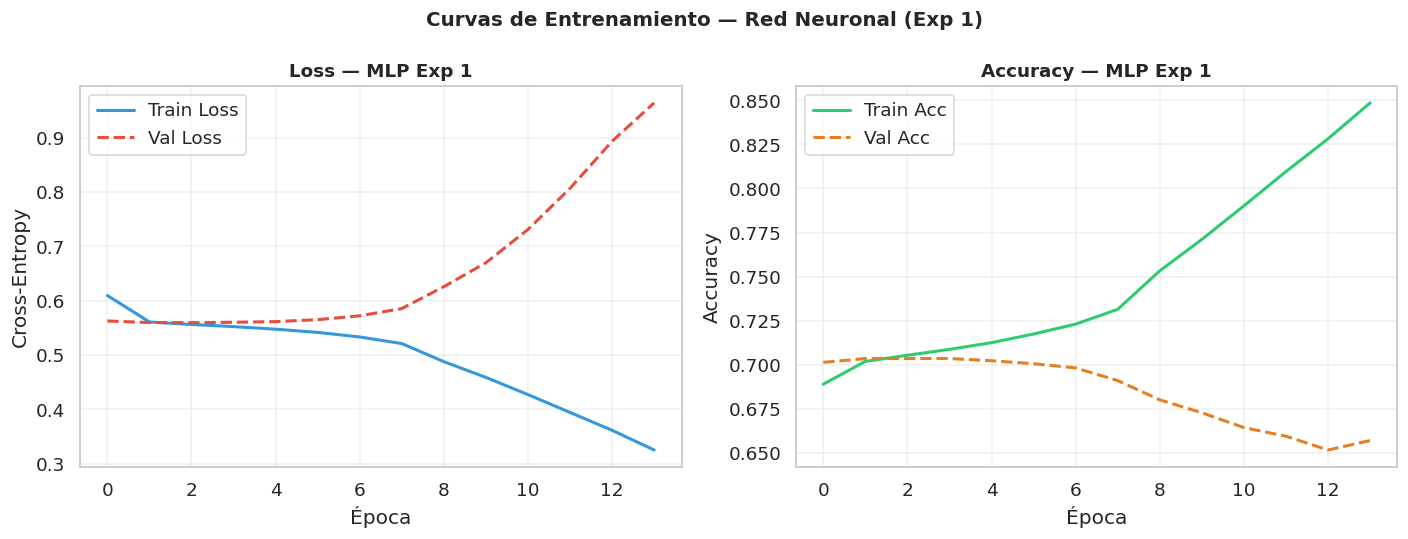

In [16]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1.history['loss'],     label='Train Loss', color='#3498DB', lw=2)
axes[0].plot(hist1.history['val_loss'], label='Val Loss',   color='#E74C3C', lw=2, ls='--')
axes[0].set_title('Loss — MLP Exp 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist1.history['accuracy'],     label='Train Acc', color='#2ECC71', lw=2)
axes[1].plot(hist1.history['val_accuracy'], label='Val Acc',   color='#E67E22', lw=2, ls='--')
axes[1].set_title('Accuracy — MLP Exp 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Red Neuronal (Exp 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fig_train_mlp_e1.png', dpi=110, bbox_inches='tight')
plt.show()


In [19]:
def evaluar(nombre, y_true, y_pred, y_prob=None, labels=None):
 
    """

    Calcula y muestra métricas completas de clasificación.

    Compatible con:

    - multiclase

    - binario

    - salidas one-hot/probabilidades

    """
 
    import numpy as np
 
    # ─────────────────────────────────────────────────────────────

    # Normalizar y_true

    # ─────────────────────────────────────────────────────────────

    y_true = np.array(y_true)
 
    # ─────────────────────────────────────────────────────────────

    # Normalizar y_pred

    # ─────────────────────────────────────────────────────────────

    y_pred = np.array(y_pred)
 
    # Caso: predicción tipo one-hot / multilabel

    # Ejemplo: [[0,1],[1,0],...]

    if len(y_pred.shape) > 1:
 
        # Si tiene más de una columna → tomar argmax

        if y_pred.shape[1] > 1:

            y_pred = np.argmax(y_pred, axis=1)
 
        # Si solo tiene una columna

        else:

            y_pred = y_pred.ravel()
 
    # ─────────────────────────────────────────────────────────────

    # Métricas principales

    # ─────────────────────────────────────────────────────────────

    acc  = accuracy_score(y_true, y_pred)
 
    f1m  = f1_score(

        y_true,

        y_pred,

        average='macro',

        zero_division=0

    )
 
    f1w  = f1_score(

        y_true,

        y_pred,

        average='weighted',

        zero_division=0

    )
 
    prec = precision_score(

        y_true,

        y_pred,

        average='macro',

        zero_division=0

    )
 
    rec  = recall_score(

        y_true,

        y_pred,

        average='macro',

        zero_division=0

    )
 
    # ─────────────────────────────────────────────────────────────

    # ROC-AUC

    # ─────────────────────────────────────────────────────────────

    auc = None
 
    if y_prob is not None:
 
        try:
 
            y_prob = np.array(y_prob)
 
            # BINARIO

            if len(np.unique(y_true)) == 2:
 
                # Caso predict_proba -> tomar prob clase positiva

                if len(y_prob.shape) > 1:

                    auc = roc_auc_score(y_true, y_prob[:, 1])

                else:

                    auc = roc_auc_score(y_true, y_prob)
 
            # MULTICLASE

            else:
 
                auc = roc_auc_score(

                    y_true,

                    y_prob,

                    multi_class='ovr',

                    average='macro'

                )
 
        except Exception as e:

            print(f'⚠️ No se pudo calcular ROC-AUC: {e}')
 
    # ─────────────────────────────────────────────────────────────

    # Mostrar métricas

    # ─────────────────────────────────────────────────────────────

    print(f'\n{"═"*58}')

    print(f'  {nombre}')

    print(f'{"═"*58}')
 
    print(f'  Accuracy            : {acc:.4f}')

    print(f'  F1-score (macro)    : {f1m:.4f}')

    print(f'  F1-score (weighted) : {f1w:.4f}')

    print(f'  Precision (macro)   : {prec:.4f}')

    print(f'  Recall (macro)      : {rec:.4f}')
 
    if auc is not None:

        print(f'  ROC-AUC             : {auc:.4f}')
 
    print()
 
    # ─────────────────────────────────────────────────────────────

    # Labels

    # ─────────────────────────────────────────────────────────────

    if labels is None:

        labels = [str(x) for x in sorted(np.unique(y_true))]
 
    print('📋 Classification Report:\n')
 
    print(

        classification_report(

            y_true,

            y_pred,

            target_names=labels,

            zero_division=0

        )

    )
 
    # ─────────────────────────────────────────────────────────────

    # Matriz de confusión

    # ─────────────────────────────────────────────────────────────

    cm = confusion_matrix(y_true, y_pred)
 
    cm_df = pd.DataFrame(

        cm,

        index=[f'Real_{l}' for l in labels],

        columns=[f'Pred_{l}' for l in labels]

    )
 
    print('\n📊 Matriz de Confusión (texto):\n')

    print(cm_df)
 
    fig, ax = plt.subplots(figsize=(7, 5))
 
    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues',

        xticklabels=labels,

        yticklabels=labels,

        linewidths=0.4,

        ax=ax

    )
 
    ax.set_title(

        f'Matriz de Confusión — {nombre}',

        fontsize=12,

        fontweight='bold'

    )
 
    ax.set_xlabel('Predicción')

    ax.set_ylabel('Real')
 
    plt.tight_layout()
 
    fn = (

        f'images/confussion_matrix/'

        f'fig_cm_{nombre.replace(" ","_").replace("(","").replace(")","").lower()}.png'

    )
 
    plt.savefig(fn, dpi=110, bbox_inches='tight')
 
    plt.show()
 
    # ─────────────────────────────────────────────────────────────

    # Retorno

    # ─────────────────────────────────────────────────────────────

    return {

        'modelo': nombre,

        'accuracy': acc,

        'f1_macro': f1m,

        'f1_weighted': f1w,

        'precision_macro': prec,

        'recall_macro': rec,

        'roc_auc': auc

    }
 

3456/3456 ━━━━━━━━━━━━━━━━━━━━ 3s 851us/step

══════════════════════════════════════════════════════════
  MLP — Exp 1 (inpu.)
══════════════════════════════════════════════════════════
  Accuracy            : 0.6995
  F1-score (macro)    : 0.6991
  F1-score (weighted) : 0.6995
  Precision (macro)   : 0.6992
  Recall (macro)      : 0.6991
  ROC-AUC             : 0.7767

📋 Classification Report:

              precision    recall  f1-score   support

        Bajo       0.71      0.71      0.71     57144
        Alto       0.69      0.69      0.69     53425

    accuracy                           0.70    110569
   macro avg       0.70      0.70      0.70    110569
weighted avg       0.70      0.70      0.70    110569


📊 Matriz de Confusión (texto):

           Pred_Bajo  Pred_Alto
Real_Bajo      40723      16421
Real_Alto      16803      36622


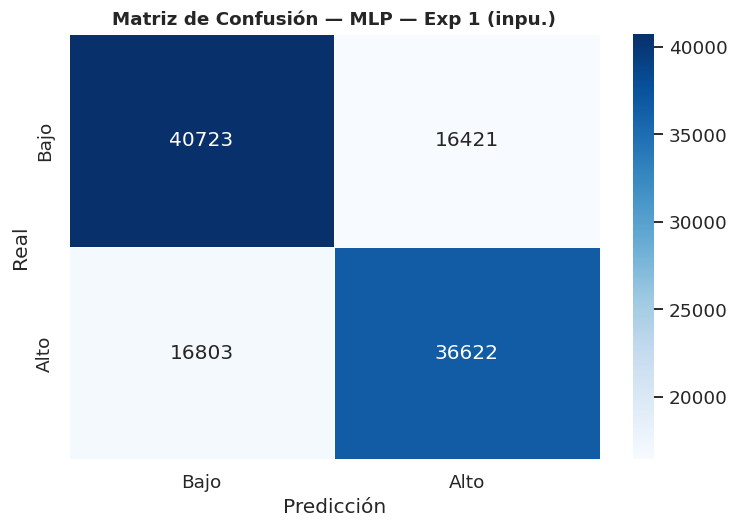

In [22]:
# ── Evaluación MLP — Exp 1 ───────────────────────────────────────────────────
ypr_nn2 = mlp1.predict(Xte_nn2)
yp_nn2  = np.argmax(ypr_nn2, axis=1)
met_nn2 = evaluar('MLP — Exp 1 (inpu.)', y_te2, yp_nn2, ypr_nn2, labels=['Bajo', 'Alto'])
